## How Many Reviews Do I Write Each Year? add line chart of count of movies watched per year.
After looking at my monthly habits, I also wanted to see how my review-writing has changed over the years. This bar chart counts exactly how many reviews I wrote each year, making it easy to spot the years I was most active at logging my thoughts. The results showed that the year that I was the most active is 2023, which connecting it to my "Movies watched per year" chart, shows that, although 2023 was not the year that I had watched the major portion of movies, bit I was tending to leave more reviews.

In [4]:
# all imports
import pandas as pd
import requests
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import numpy as np
import squarify
import pandas as pd
import plotly.express as px


/var/folders/4t/r2dg52q53m5_t64tj26d8ljm0000gn/T/ipykernel_41115/4227908774.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


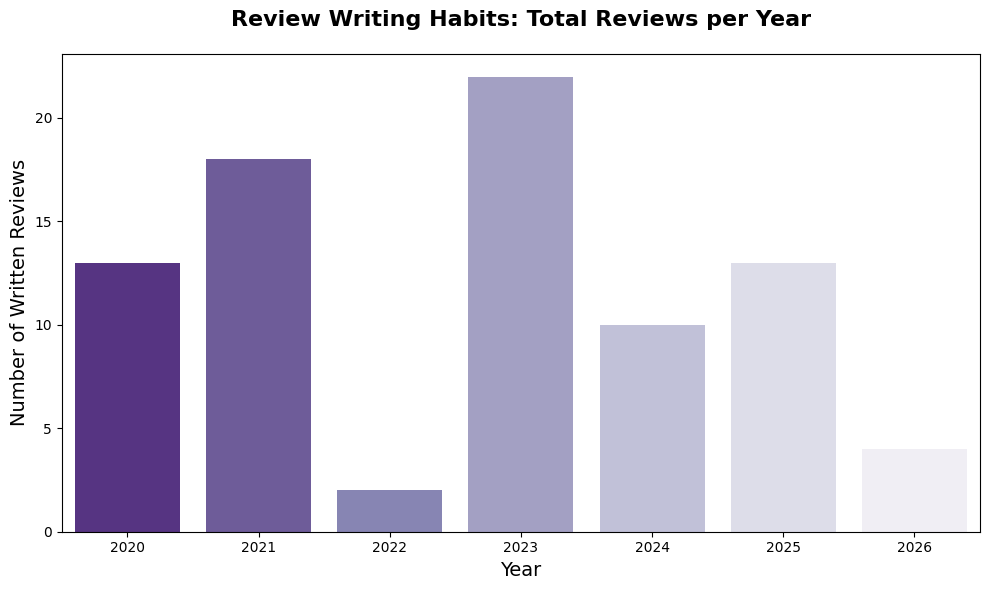

In [5]:

df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')

#Filter for movies that actually have written reviews
df_reviews_only = df[df['Review'].notna() & (df['Review'].str.strip() != '')].copy()

df_reviews_only['Watched Date'] = pd.to_datetime(df_reviews_only['Watched Date'])
df_reviews_only['Year'] = df_reviews_only['Watched Date'].dt.year

# reviews written each year and sort chronologically
reviews_per_year = df_reviews_only['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=reviews_per_year.index.astype(int), 
    y=reviews_per_year.values, 
    palette='Purples_r' 
)

plt.title('Review Writing Habits: Total Reviews per Year', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Written Reviews', fontsize=14)
plt.tight_layout()

plt.show()

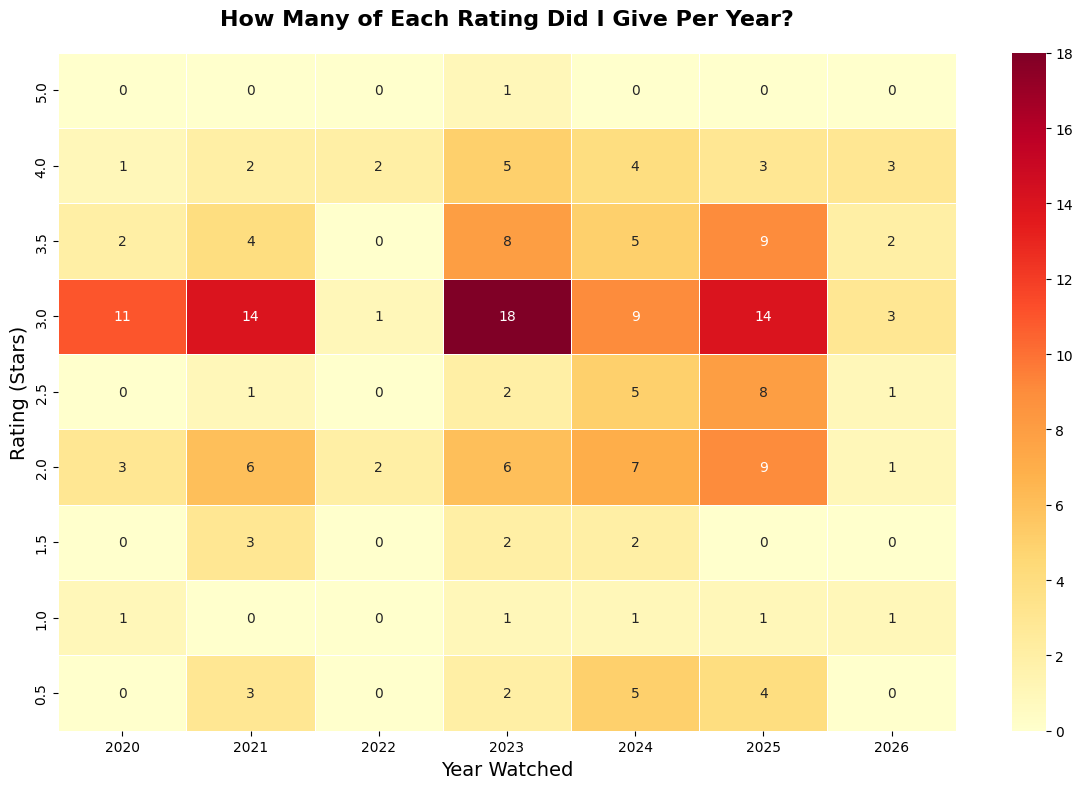

In [6]:


df = pd.read_csv('Dataset/main_enrichedwithcountry_full.csv')
df['Watched Date'] = pd.to_datetime(df['Watched Date'])
df['Watched Year'] = df['Watched Date'].dt.year

# Rows = Ratings, Columns = Years
rating_year_pivot = df.groupby(['Rating', 'Watched Year']).size().unstack(fill_value=0)

# Sort the ratings
rating_year_pivot = rating_year_pivot.sort_index(ascending=False)

#the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    rating_year_pivot, 
    annot=True,      
    fmt="d",         
    cmap="YlOrRd",   
    linewidths=.5
)

plt.title('How Many of Each Rating Did I Give Per Year?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year Watched', fontsize=14)
plt.ylabel('Rating (Stars)', fontsize=14)

plt.tight_layout()
plt.show()